## 3. SkipGram Model Embeding

**Example**
Consider the sentence:

> "the cat sat on the mat"

- If the window size is 2, for the center word "sat", the context words are: "the", "cat", "on", "the".

- Skip-gram tries to maximize the probability of these context words given the center word "sat".

---

**Intuition**
- Words that appear in similar contexts get embeddings close in vector space.
- For example, "cat" and "dog" might have similar embeddings because they share many common context words.

---

#### Mathematical Approach

- Center word vector (cat):  
$$
\mathbf{v}_{w_c} = [1, 0]
$$

- Positive context word vector (furry):  
$$
\mathbf{v}_{w_o} = [0.8, 0.2]
$$

- Negative sample word vector (car):  
$$
\mathbf{v}_{w_{neg}} = [-0.5, 0.3]
$$



**Step 1: Dot product (similarity)**

For the **positive pair** ("cat", "furry"):  
$$
\mathbf{v}_{w_o}^\top \mathbf{v}_{w_c} = (0.8 \times 1) + (0.2 \times 0) = 0.8
$$

For the **negative pair** ("cat", "car"):  
$$
\mathbf{v}_{w_{neg}}^\top \mathbf{v}_{w_c} = (-0.5 \times 1) + (0.3 \times 0) = -0.5
$$



**Step 2: Sigmoid function (converts similarity to probability)**

Recall sigmoid:  
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Apply sigmoid to positive pair dot product:  
$$
\sigma(0.8) = \frac{1}{1 + e^{-0.8}} \approx 0.69
$$

Apply sigmoid to **negated** negative pair dot product:  
$$
\sigma(-\mathbf{v}_{w_{neg}}^\top \mathbf{v}_{w_c}) = \sigma(0.5) = \frac{1}{1 + e^{-0.5}} \approx 0.62
$$



**Step 3: Log probabilities**

For positive pair:  
$$
\log \sigma(\mathbf{v}_{w_o}^\top \mathbf{v}_{w_c}) = \log(0.69) \approx -0.37
$$

For negative pair:  
$$
\log \sigma(-\mathbf{v}_{w_{neg}}^\top \mathbf{v}_{w_c}) = \log(0.62) \approx -0.48
$$



**Step 4: Objective to maximize (sum of log probabilities)**

$$
J = \log \sigma(\mathbf{v}_{w_o}^\top \mathbf{v}_{w_c}) + \log \sigma(-\mathbf{v}_{w_{neg}}^\top \mathbf{v}_{w_c}) = -0.37 + (-0.48) = -0.85
$$



**Step 5: Loss function (to minimize)**

We minimize the negative of the objective:  
$$
\text{Loss} = -J = 0.85
$$

---

**Intuition recap:**

- The model learns to **increase** $$ \sigma(\mathbf{v}_{w_o}^\top \mathbf{v}_{w_c}) $$ (positive pair similarity)  
- And **increase** $$ \sigma(-\mathbf{v}_{w_{neg}}^\top \mathbf{v}_{w_c}) $$ (negative pair dissimilarity)  
- This pushes positive pairs closer and negative pairs farther apart in embedding space.


#### Benefits

- Reduces computation dramatically, allowing training on very large vocabularies  
- Focuses learning on distinguishing true context words from noise  
- Enables efficient stochastic gradient updates

---


**Step 1: Prepare Corpus and Vocabulary**

```txt
mouse ran away from the cat the fish swims in the water birds fly in the sky
the cat sat on the mat the dog chased the cat cats and dogs are animals the 
```

In [8]:
corpus = "the cat sat on the mat the dog chased the cat cats and dogs are animals the " \
          "mouse ran away from the cat the fish swims in the water birds fly in the sky"
words = corpus.lower().split()

# Build vocabulary of unique words
vocab = list(set(words))
word2idx = {word: i for i, word in enumerate(vocab)}
idx2word = {i: word for word, i in word2idx.items()}

print(f"Vocabulary Size: {len(vocab)}")
print(f"Vocabulary: {vocab}")


Vocabulary Size: 23
Vocabulary: ['fish', 'are', 'from', 'birds', 'fly', 'sat', 'dogs', 'cat', 'away', 'sky', 'cats', 'mat', 'and', 'swims', 'ran', 'the', 'water', 'in', 'animals', 'on', 'mouse', 'dog', 'chased']


**Step 2: Generate Training Pairs (Center Word, Context Word)**

In [9]:
window_size = 2
training_pairs = []

for i, center_word in enumerate(words):
    center_idx = word2idx[center_word]
    start = max(i - window_size, 0)
    end = min(i + window_size + 1, len(words))
    
    for j in range(start, end):
        if i != j:
            context_idx = word2idx[words[j]]
            training_pairs.append((center_idx, context_idx))

print(f"Corups: {corpus} \n\n")

print(f"Number of training pairs: {len(training_pairs)}")
print(f"Sample training pairs (indices): {training_pairs[:5]}")

# Display some training pairs
print("\n\nSample training pairs (words):")
for item in training_pairs[:10]:
    center_word = idx2word[item[0]]
    context_word = idx2word[item[1]]
    print(f"Center: {center_word}, Context: {context_word}")


Corups: the cat sat on the mat the dog chased the cat cats and dogs are animals the mouse ran away from the cat the fish swims in the water birds fly in the sky 


Number of training pairs: 130
Sample training pairs (indices): [(15, 7), (15, 5), (7, 15), (7, 5), (7, 19)]


Sample training pairs (words):
Center: the, Context: cat
Center: the, Context: sat
Center: cat, Context: the
Center: cat, Context: sat
Center: cat, Context: on
Center: sat, Context: the
Center: sat, Context: cat
Center: sat, Context: on
Center: sat, Context: the
Center: on, Context: cat


**Step 3. Negative Samples Generation:**

Let's see the example below to understand what it does

---

**i. Vocabulary setup:**
- The code starts with a small vocabulary of 5 words: "cat", "dog", "mouse", "bird", and "fish". 
- Each word is assigned a unique index (for example, "cat" → 0, "dog" → 1, and so on). This allows the program to work with numbers instead of raw text.

**ii. Training pairs:**
- The code simulates pairs of words that appear together in a text. 
For instance, (cat, dog) means "dog" appears near "cat" in some sentence. These pairs are stored as indices: (0, 1) for (cat, dog).

**iii. Negative sampling function:**
- For each positive pair like (cat, dog), the model needs to learn which words do not belong as context words for "cat". 
- The function randomly picks words from the vocabulary that are not the positive context word (here, not "dog"). 
- For example, it might randomly pick "bird", "fish", and "mouse" as negative samples for "dog".

**iv. Generating negatives for one pair:**
- Taking the first training pair (cat, dog), the code extracts the positive context word index (dog → 1). 
- Then it calls the negative sampling function to get 3 negative samples—random words other than "dog". These might be [2, 3, 4], corresponding to "mouse", "bird", and "fish".

**v. Word vectors for illustration:**
- Each word is assigned a simple 2D vector, like "cat" → [0.1, 0.2], "dog" → [0.3, 0.4], etc. 
- These vectors represent the words numerically, as would happen inside an embedding model.
---

> Example

In [10]:
import numpy as np

def get_negative_samples(pos_context_idx, num_negatives=5, vocab_size=None):
    """Negative sampling function to generate negative samples."""
    if vocab_size is None:
        raise ValueError("vocab_size must be specified")
    neg_samples = []
    while len(neg_samples) < num_negatives:
        neg = np.random.randint(0, vocab_size)
        if neg != pos_context_idx and neg not in neg_samples:  # avoid duplicates
            neg_samples.append(neg)
    return neg_samples


# Example training pairs (center_word_idx, context_word_idx)

# Define vocab and mappings first
example_vocab = ["cat", "dog", "mouse", "bird", "fish"]
example_word2idx = {w: i for i, w in enumerate(example_vocab)}
example_idx2word = {i: w for i, w in enumerate(example_vocab)}

example_training_pairs = [
    (example_word2idx["cat"], example_word2idx["dog"]),
    (example_word2idx["cat"], example_word2idx["mouse"]),
    (example_word2idx["dog"], example_word2idx["fish"]),
    # ... add more pairs as needed
]

# Get positive context index from the first training pair
example_pos_context_idx = example_training_pairs[0][1]

# Get negative samples: 3 samples example
example_negative_samples = get_negative_samples(
    example_pos_context_idx, num_negatives=3, vocab_size=len(example_vocab)
)

print(f"Positive Context Index: {example_pos_context_idx}")
print(f"Negative Samples: {example_negative_samples}\n")

# Vocab vectors (example)
example_vocab_vectors = {
    "cat": np.array([0.1, 0.2]),
    "dog": np.array([0.3, 0.4]),
    "mouse": np.array([0.5, 0.6]),
    "bird": np.array([0.7, 0.8]),
    "fish": np.array([0.9, 1.0])
}

# Get positive word and vector
pos_word = example_idx2word[example_pos_context_idx]
pos_vector = example_vocab_vectors[pos_word]

# Get negative words and vectors
neg_vectors = [example_vocab_vectors[example_idx2word[neg]] for neg in example_negative_samples]

print(f"Positive Word: {pos_word}, Vector: {pos_vector}\n\n")

print("Negative Samples and their Vectors:")
for neg, vec in zip(example_negative_samples, neg_vectors):
    neg_word = example_idx2word[neg]
    print(f"Negative Word Index: {neg}: {neg_word}, Vector: {vec}")


Positive Context Index: 1
Negative Samples: [4, 3, 0]

Positive Word: dog, Vector: [0.3 0.4]


Negative Samples and their Vectors:
Negative Word Index: 4: fish, Vector: [0.9 1. ]
Negative Word Index: 3: bird, Vector: [0.7 0.8]
Negative Word Index: 0: cat, Vector: [0.1 0.2]


**Step 4: Define Skip-gram Model**

In [11]:
import torch
import torch.nn as nn

class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.in_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.out_embeddings = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, center_words, context_words):
        center_embeds = self.in_embeddings(center_words)     # (batch, emb_dim)
        context_embeds = self.out_embeddings(context_words)  # (batch, emb_dim)
        dot_products = torch.sum(center_embeds * context_embeds, dim=1)  # batch dot product
        return dot_products

**5. Train Model:**

In [12]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SkipGramModel(len(vocab), embedding_dim=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

epochs = 100
batch_size = 64

for epoch in range(epochs):
    np.random.shuffle(training_pairs)
    total_loss = 0

    for i in range(0, len(training_pairs), batch_size):
        batch = training_pairs[i:i+batch_size]
        
        center_batch = []
        context_batch = []
        labels = []

        for center_idx, context_idx in batch:
            # Positive pair
            center_batch.append(center_idx)
            context_batch.append(context_idx)
            labels.append(1)

            # Negative pairs
            neg_samples = get_negative_samples(context_idx, num_negatives=5, vocab_size=len(vocab))
            for neg in neg_samples:
                center_batch.append(center_idx)
                context_batch.append(neg)
                labels.append(0)

        center_batch = torch.tensor(center_batch).to(device)
        context_batch = torch.tensor(context_batch).to(device)
        labels = torch.tensor(labels, dtype=torch.float32).to(device)

        optimizer.zero_grad()
        outputs = model(center_batch, context_batch)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")


Epoch [10/100], Loss: 3.1915
Epoch [20/100], Loss: 2.5439
Epoch [30/100], Loss: 2.4269
Epoch [40/100], Loss: 1.9152
Epoch [50/100], Loss: 1.6590
Epoch [60/100], Loss: 1.4623
Epoch [70/100], Loss: 1.2216
Epoch [80/100], Loss: 1.7581
Epoch [90/100], Loss: 1.4725
Epoch [100/100], Loss: 1.2389


**Step 6: Visualize the Learned Embeddings**

Corpus: the cat sat on the mat the dog chased the cat cats and dogs are animals the mouse ran away from the cat the fish swims in the water birds fly in the sky


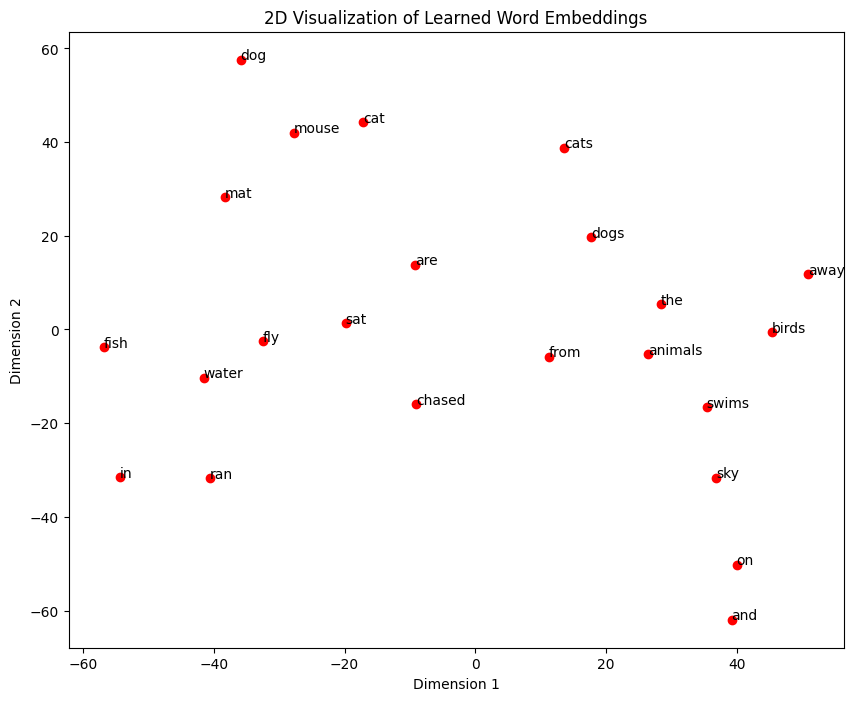

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("Corpus:", corpus)

# Extract embeddings (input embeddings)
embeddings = model.in_embeddings.weight.detach().cpu().numpy()

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='red')

for i, word in enumerate(vocab):
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.title("2D Visualization of Learned Word Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()
